# Downloading the PolarGAP airborne gravity survey to use in the notebooks

Accessed from: https://ramadda.data.bas.ac.uk/repository/entry/show?entryid=32ac27a1-abe0-4f33-ba30-65a093511fb8
Survey can be viewed here: https://bas.maps.arcgis.com/apps/instant/media/index.html?appid=c1a658ec78d54be18da570e955c278ca#
Some more info here: https://antarctica.github.io/PDC_GeophysicsBook/data-portal/data_available.html#polargap-2015-16
Metadata here: https://data.bas.ac.uk/full-record.php?id=GB/NERC/BAS/PDC/01583

Processing notes:

The ESA PolarGap airborne gravity, lidar/radar and aeromagnetic survey was carried out in Antarctica in the field season 2015/16. The purpose of the 2015/16 ESA PolarGAP airborne survey of the South Pole region was to fill the gap in satellite gravity coverage, enabling construction of accurate global geoid models. Additional radar flights over the Recovery Lakes for the Norwegian Polar Institute (NPI) were carried out as part of the same survey, but included collection of airborne gravity. Gravity data were collected using two complimentary systems. The primary system was a ZLS-modified Lacoste and Romberg (LCR) gravimeter (S-83) which gives exceptionally low and predictable long term drift. The secondary system was high specification inertial navigation system (iMAR RQH-1003), provided by TU Darmstadt, capable of resolving gravity anomalies even under turbulent conditions, but more prone to instrument drift. Results from both systems were merged to give a unified best product. The aircraft used was the BAS aerogeophysicaly equipped twin otter VP-FBL. Data are available as an ASCII table (.csv).

Data resolution:
The radial design of the survey makes defining a specific resolution problematic. Line spacing at the survey edges was 90 km, reducing towards South Pole. The along track resolution is 6 km half-width based on the imposed filtering.

Lineage/Methodology:	
The airborne gravity measurements from the LCR gravimeter S-83 were corrected for aircraft dynamic movement using precise point positioning (ppp) GPS solutions following the methodology of Olesen et al 2002. Gravity from the iMAR RQH sensor was processed using a Kalman filtering approach to provide independent gravity estimates (Becker et al 2015). These independent estimates of the gravity field were combined using a Technical University of Denmark (DTU) in-house draping approach. This ensures that the long-wavelength, bias-stable LCR data are optimally merged with the more linear, but drifting, results of the iMAR RQH sensor.
The processing parameters for the LCR gravity data included a 130-150 sec 2nd order Butterworth along-track filtering, corresponding to a spacing on the ground of ca. 6 km. The flight elevations were generally low level (1200 ft AGL), but occasionally higher due to fog or low-level clouds; flight altitudes varied between 2.9 and 4.3 km.
The overall accuracy of the airborne processing was 2.2 mGal r.m.s., as inferred from 129-xover points, not taking into account the difference in heights at the cross-over points. This is a highly satisfactory result, given the rough conditions (field camps and temperatures down to -30degC), and the fact that the BAS Twin-Otter did not have an autopilot, which is usually a requirement for high-quality, bias-free aerogravity. No cross-over adjustment was performed on the data, so the data level of every single line is determined only by the gravimeter "apron" values, i.e. the stationary readings before or after flights. The gravity ties used to define absolute gravity values constraining the survey level were done with LCR land gravimeters G-784 (BAS) and G-867 (DTU), linked to earlier surveys and reference stations at McMurdo and Rothera, and adjusted in a least-squares process.

Data Collection:	
Data was collected using the BAS aerogeophysicaly equipped twin otter VP-FBL. Two gravity systems were used: A ZLS-modified Lacoste and Romberg (LCR) gravimeter S-83 which is a stabilised platform type sensor, and a high grade inertial navigation unit, iMAR RQH-1003, provided by TU Darmstadt, which acted as a so-called strapdown gravity sensor. Data from both these instruments was merged to give an optimal final product.

The aerogravity data set includes the following channels:
* Fiducial: line_no*10000+running no
* latitude_decimal_degrees: DD.DDDDD
* longitude_decimal_degrees: DDD.DDDDD
* ellipsoidal_height_m: Elevation referenced to WGS1984 ellipsoid (m)
* gravity_disturbance_mGal: Gravity variations corrected to the WGS1984 ellipsoid (mGal)
* gravity_anomaly_mGal: Free air gravity anomalies corrected to the GOCE R5 geoid (mGal)

In [1]:
%load_ext autoreload
%autoreload 2

import harmonica as hm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
import pooch
import seaborn as sns
import verde as vd

import airbornegeo

pio.renderers.default = "notebook"

## Load data

In [3]:
path = pooch.retrieve(
    url="https://ramadda.data.bas.ac.uk/repository/entry/get/PolarGAP_gravity_release.csv?entryid=synth:32ac27a1-abe0-4f33-ba30-65a093511fb8:L1BvbGFyR0FQX2dyYXZpdHlfcmVsZWFzZS5jc3Y=",
    fname="PolarGAP_gravity_release.csv",
    path=f"{pooch.os_cache('airbornegeo')}",
    known_hash="23b574ddee4aec32a4f2b4318a94a3f4c1592edba20d6c2e2167f28242c65306",
    progressbar=True,
)

In [ ]:
data_df = pd.read_csv(path, na_values=["*"])

# fiducial is line_no * 10000 + running no
data_df["line_no"] = data_df.Fiducial / 10e3
data_df["line_no"] = data_df["line_no"].astype(int)

# change line id to start sequentially from 1
data_df["line"] = airbornegeo.unique_line_id(data_df, "line_no")

data_df

In [63]:
data_df.describe()

,Fiducial,latitude_decimal_degrees,longitude_decimal_degrees,ellipsoidal_height_m,Gravity_disturbance_mGal,gravity_anomaly_mGal,line_no,line
count,4.559700e+04,45597.000000,45597.000000,45597.000000,45597.000000,45597.000000,45597.000000,45597.000000
mean,6.375335e+05,-86.048929,-24.510446,2911.716774,-22.152389,-15.230927,63.428690,56.903809
std,2.873984e+05,2.006619,70.888902,451.709167,36.383963,36.124052,28.714862,26.519137
min,4.001000e+04,-89.997400,-170.573450,1551.690000,-162.400000,-154.186000,4.000000,1.000000
25%,4.534200e+05,-87.691220,-79.150910,2801.440000,-47.500000,-40.066000,45.000000,41.000000
50%,6.812700e+05,-85.841530,-30.002950,2923.410000,-28.000000,-20.757000,68.000000,61.000000
75%,8.722100e+05,-84.594100,18.310790,3207.800000,3.400000,9.345000,87.000000,79.000000
max,1.221260e+06,-81.144880,142.642960,4342.640000,175.800000,185.508000,122.000000,105.000000


## Reproject

In [64]:
# reproject to EPSG:3031 Polar Stereographic
data_df["easting"], data_df["northing"] = airbornegeo.reproject(
    data_df.longitude_decimal_degrees,
    data_df.latitude_decimal_degrees,
    input_crs="EPSG:4326",
    output_crs="EPSG:3031",
)
data_df.head()

,Fiducial,latitude_decimal_degrees,longitude_decimal_degrees,ellipsoidal_height_m,Gravity_disturbance_mGal,gravity_anomaly_mGal,line_no,line,easting,northing
0,40010,-81.14488,-38.74183,2784.87,-9.2,-3.575,4,1,-603265.926411,751873.371495
1,40020,-81.14804,-38.71200,2784.86,-9.3,-3.676,4,1,-602658.432454,751917.898625
2,40030,-81.15137,-38.68235,2784.85,-9.3,-3.677,4,1,-602041.808259,751945.605104
3,40040,-81.15456,-38.65225,2784.85,-9.4,-3.778,4,1,-601428.967250,751989.547131
4,40050,-81.15767,-38.62209,2784.85,-9.4,-3.779,4,1,-600820.916289,752040.513153


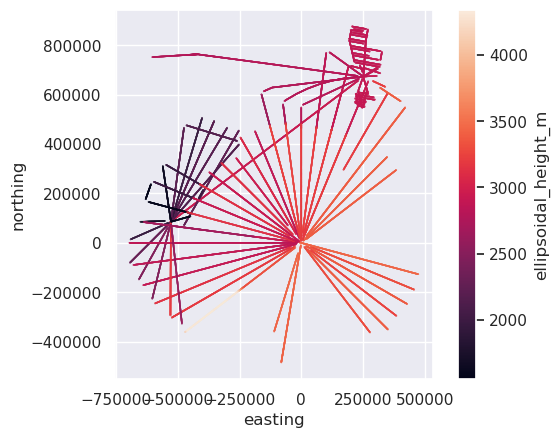

In [65]:
data_df.plot.scatter(
    "easting",
    "northing",
    c="ellipsoidal_height_m",
    s=0.02,
).set_aspect("equal")

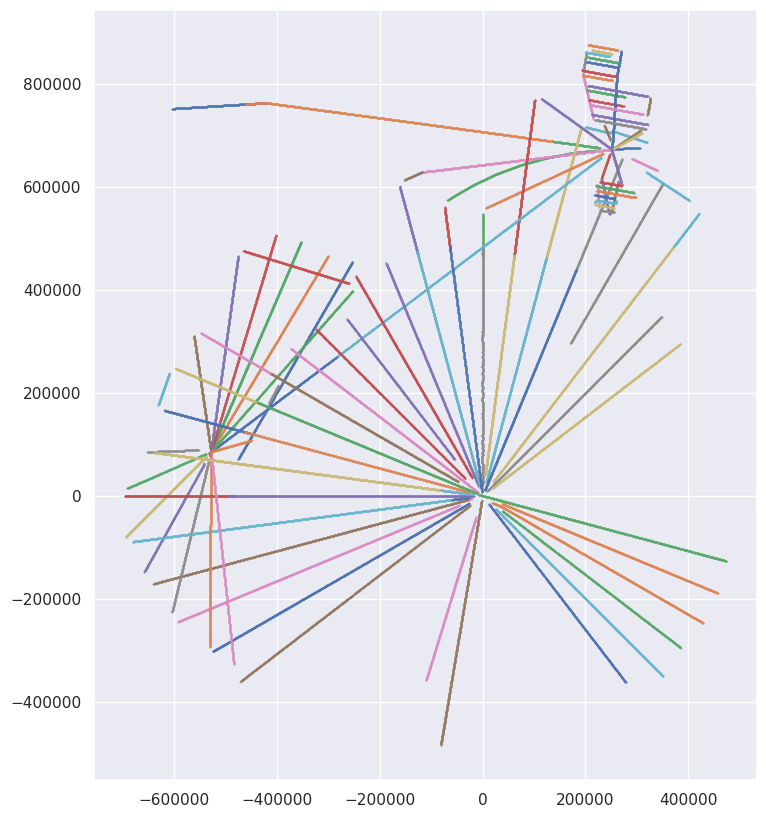

In [66]:
fig, ax = plt.subplots(figsize=(10, 10))
for _line_num, line_data in data_df.groupby("line"):
    # plot points
    ax.scatter(
        line_data.easting,
        line_data.northing,
        s=0.1,
    )
ax.set_aspect("equal")

In [ ]:
survey = airbornegeo.Survey(
    data_df,
    line_column="line",
    distance_column="distance_along_line",
)
survey.along_track_distance()
data_df = survey.data
data_df.head()

In [ ]:
survey.plot(color_by="distance_along_line", s=0.02)

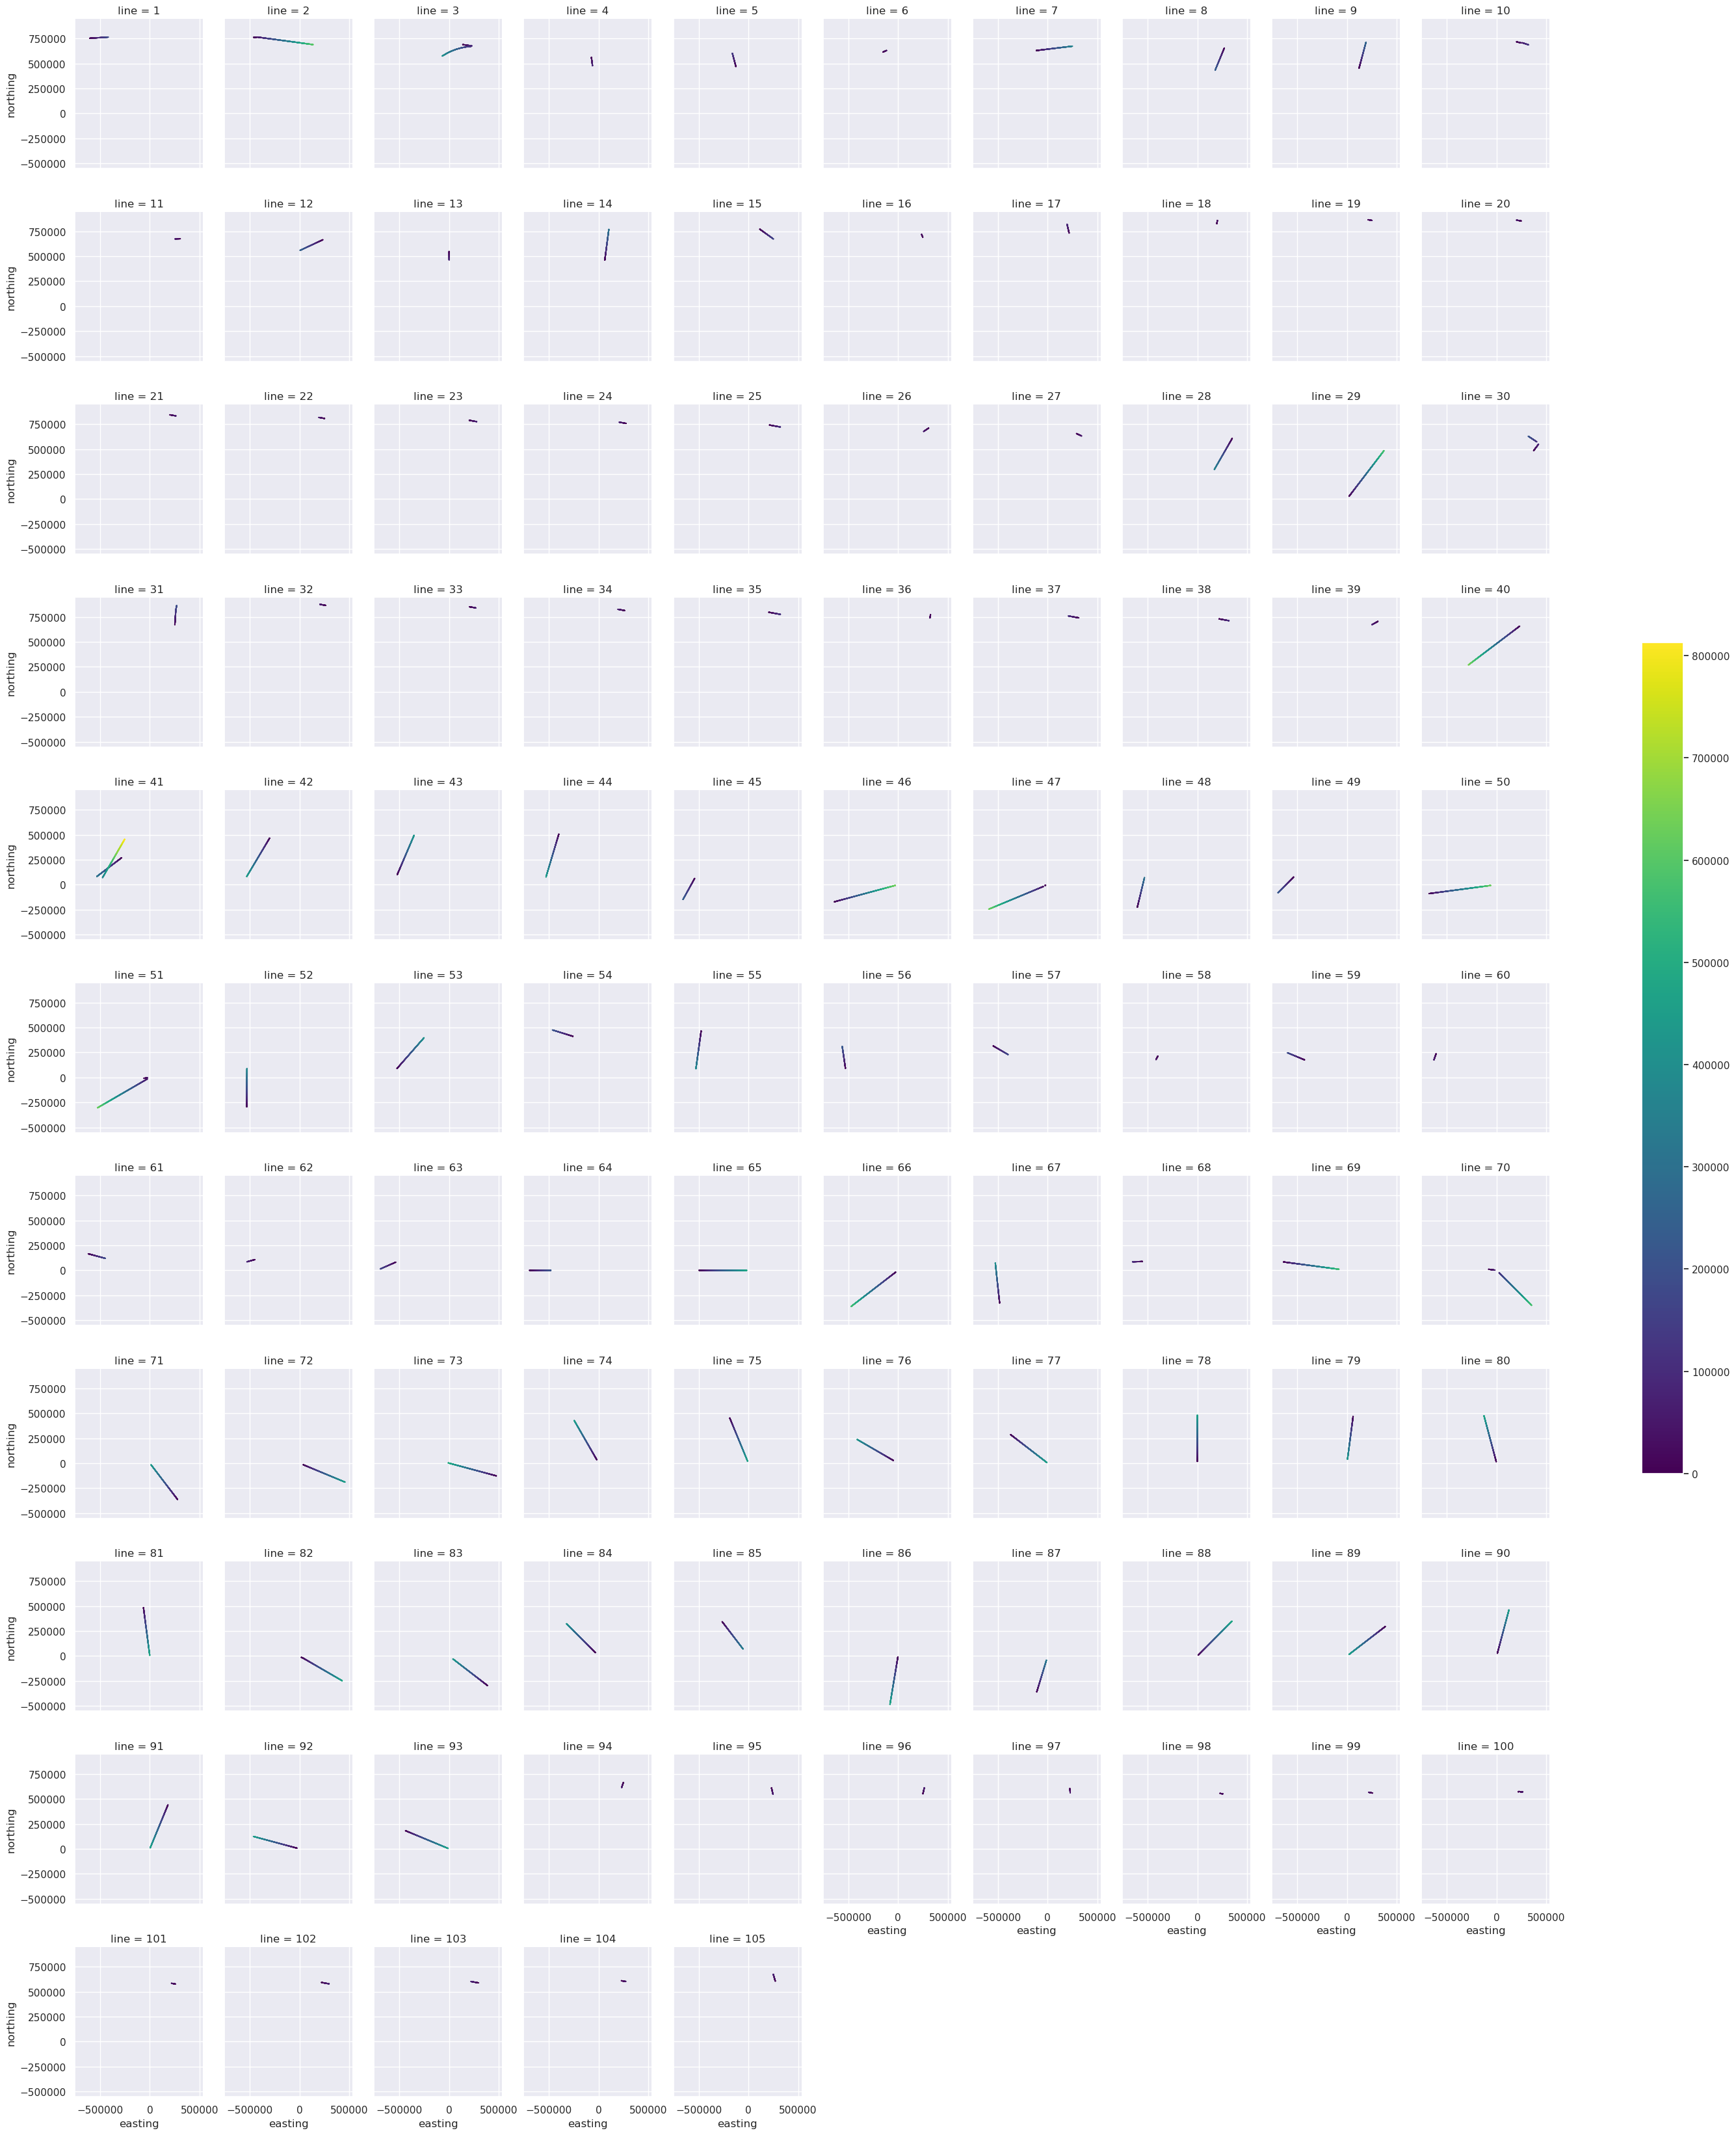

In [70]:
# plot each line
df = data_df

grid = sns.FacetGrid(
    df,
    col="line",
    col_wrap=int(len(df.line.unique()) ** 0.5),
)

norm = plt.Normalize(
    vmin=df.distance_along_line.min(), vmax=df.distance_along_line.max()
)

grid.map_dataframe(
    sns.scatterplot,
    "easting",
    "northing",
    "distance_along_line",
    palette="viridis",
    hue_norm=norm,
    edgecolor="none",
    s=2,
)

sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = grid.figure.colorbar(sm, ax=grid.axes.ravel().tolist(), shrink=0.4)

## Examine gravity data

In [71]:
data_df.columns

Index(['Fiducial', 'latitude_decimal_degrees', 'longitude_decimal_degrees',
       'ellipsoidal_height_m', 'Gravity_disturbance_mGal',
       'gravity_anomaly_mGal', 'line_no', 'line', 'easting', 'northing',
       'geometry', 'distance_along_line'],
      dtype='str')

In [72]:
data_df[["Gravity_disturbance_mGal", "gravity_anomaly_mGal"]].head()

,Gravity_disturbance_mGal,gravity_anomaly_mGal
0,-9.2,-3.575
1,-9.3,-3.676
2,-9.3,-3.677
3,-9.4,-3.778
4,-9.4,-3.779


In [73]:
data_df[["Gravity_disturbance_mGal", "gravity_anomaly_mGal"]].describe()

,Gravity_disturbance_mGal,gravity_anomaly_mGal
count,45597.000000,45597.000000
mean,-22.152389,-15.230927
std,36.383963,36.124052
min,-162.400000,-154.186000
25%,-47.500000,-40.066000
50%,-28.000000,-20.757000
75%,3.400000,9.345000
max,175.800000,185.508000


In [ ]:
survey.plot(color_by="Gravity_disturbance_mGal", s=0.02)

In [ ]:
survey.plot(color_by="gravity_anomaly_mGal", s=0.02)

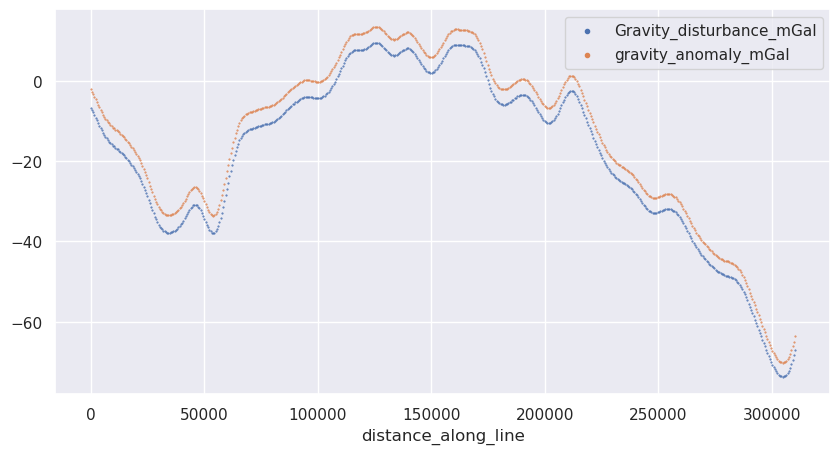

In [77]:
fig = airbornegeo.plot_profiles(
    data_df[data_df.line == 14],
    y=("Gravity_disturbance_mGal", "gravity_anomaly_mGal"),
    x="distance_along_line",
)

In [78]:
data_df.to_csv("../data/PolarGAP_gravity_survey.csv", index=False)

In [93]:
data_df = pd.read_csv("../data/PolarGAP_gravity_survey.csv")
data_df

,Fiducial,latitude_decimal_degrees,longitude_decimal_degrees,ellipsoidal_height_m,Gravity_disturbance_mGal,gravity_anomaly_mGal,line_no,line,easting,northing,geometry,distance_along_line
0,40010,-81.14488,-38.74183,2784.87,-9.2,-3.575,4,1,-603265.926411,751873.371495,POINT (-603265.9264107548 751873.3714952277),0.000000
1,40020,-81.14804,-38.71200,2784.86,-9.3,-3.676,4,1,-602658.432454,751917.898625,POINT (-602658.4324541363 751917.8986249841),609.123610
2,40030,-81.15137,-38.68235,2784.85,-9.3,-3.677,4,1,-602041.808259,751945.605104,POINT (-602041.8082592422 751945.6051041025),1226.369952
3,40040,-81.15456,-38.65225,2784.85,-9.4,-3.778,4,1,-601428.967250,751989.547131,POINT (-601428.9672503384 751989.5471308591),1840.784311
4,40050,-81.15767,-38.62209,2784.85,-9.4,-3.779,4,1,-600820.916289,752040.513153,POINT (-600820.9162888281 752040.5131525936),2450.967486
...,...,...,...,...,...,...,...,...,...,...,...,...
45592,1221220,-83.40000,20.42698,2899.63,-70.4,-67.202,122,105,250545.546783,672726.897042,POINT (250545.5467832175 672726.8970418533),69339.545404
45593,1221230,-83.39572,20.40074,2898.87,-69.9,-66.701,122,105,250400.049295,673278.825916,POINT (250400.04929548543 673278.8259160124),69910.329953
45594,1221240,-83.39148,20.37734,2898.32,-69.2,-66.001,122,105,250285.980997,673814.271927,POINT (250285.98099719553 673814.2719269376),70457.791374
45595,1221250,-83.38725,20.35629,2898.00,-68.6,-65.401,122,105,250198.796976,674338.455428,POINT (250198.79697590342 674338.4554279465),70989.175789


In [ ]:
# block reduce the line data (data_df was reloaded from CSV above, so
# rebuild the Survey from it rather than reusing the earlier one)
survey = airbornegeo.Survey(
    data_df, line_column="line", distance_column="distance_along_line"
)
survey = survey.block_reduce(
    np.median,
    spacing=2e3,
    # reduce_by=('easting','northing'),
    reduce_by="distance_along_line",
)
data_df = survey.data
data_df

In [95]:
data_df.to_csv("../data/PolarGAP_gravity_survey_blocked.csv", index=False)

In [45]:
break  # noqa: F701

SyntaxError: 'break' outside loop (2219531815.py, line 1)

In [96]:
data_df = pd.read_csv("../data/PolarGAP_gravity_survey_blocked.csv")
data_df

,distance_along_line,tmp,Fiducial,latitude_decimal_degrees,longitude_decimal_degrees,ellipsoidal_height_m,Gravity_disturbance_mGal,gravity_anomaly_mGal,line_no,line,easting,northing
0,917.746781,0.0,40025.0,-81.149705,-38.697175,2784.855,-9.3,-3.6765,4.0,1,-602350.120357,751931.751865
1,3062.544403,0.0,40060.0,-81.160890,-38.592310,2784.860,-9.5,-3.8800,4.0,1,-600210.469324,752077.672651
2,4894.960238,0.0,40090.0,-81.170560,-38.503120,2784.980,-9.8,-4.1830,4.0,1,-598381.166423,752184.148885
3,7021.612558,0.0,40125.0,-81.181600,-38.398660,2785.130,-11.2,-5.5865,4.0,1,-596259.512926,752328.349461
4,9143.716281,0.0,40160.0,-81.192660,-38.294490,2784.960,-14.0,-8.3900,4.0,1,-594141.757244,752462.714587
...,...,...,...,...,...,...,...,...,...,...,...,...
14118,62575.308980,0.0,1221100.0,-83.449290,20.756100,2908.640,-73.4,-70.2160,122.0,105,252501.746958,666252.862380
14119,64539.161722,0.0,1221135.0,-83.434875,20.661460,2907.920,-72.7,-69.5125,122.0,105,251955.219831,668139.134848
14120,66516.392894,0.0,1221170.0,-83.420670,20.562920,2905.010,-72.1,-68.9080,122.0,105,251349.621996,670021.115311
14121,68486.712981,0.0,1221205.0,-83.406335,20.466950,2901.090,-71.1,-67.9035,122.0,105,250773.281353,671905.033246


In [97]:
data_df = data_df.dropna(
    subset=["easting", "northing", "ellipsoidal_height_m", "gravity_anomaly_mGal"]
)

coords = (
    data_df.easting,
    data_df.northing,
    data_df.ellipsoidal_height_m,
)
data_df

,distance_along_line,tmp,Fiducial,latitude_decimal_degrees,longitude_decimal_degrees,ellipsoidal_height_m,Gravity_disturbance_mGal,gravity_anomaly_mGal,line_no,line,easting,northing
0,917.746781,0.0,40025.0,-81.149705,-38.697175,2784.855,-9.3,-3.6765,4.0,1,-602350.120357,751931.751865
1,3062.544403,0.0,40060.0,-81.160890,-38.592310,2784.860,-9.5,-3.8800,4.0,1,-600210.469324,752077.672651
2,4894.960238,0.0,40090.0,-81.170560,-38.503120,2784.980,-9.8,-4.1830,4.0,1,-598381.166423,752184.148885
3,7021.612558,0.0,40125.0,-81.181600,-38.398660,2785.130,-11.2,-5.5865,4.0,1,-596259.512926,752328.349461
4,9143.716281,0.0,40160.0,-81.192660,-38.294490,2784.960,-14.0,-8.3900,4.0,1,-594141.757244,752462.714587
...,...,...,...,...,...,...,...,...,...,...,...,...
14118,62575.308980,0.0,1221100.0,-83.449290,20.756100,2908.640,-73.4,-70.2160,122.0,105,252501.746958,666252.862380
14119,64539.161722,0.0,1221135.0,-83.434875,20.661460,2907.920,-72.7,-69.5125,122.0,105,251955.219831,668139.134848
14120,66516.392894,0.0,1221170.0,-83.420670,20.562920,2905.010,-72.1,-68.9080,122.0,105,251349.621996,670021.115311
14121,68486.712981,0.0,1221205.0,-83.406335,20.466950,2901.090,-71.1,-67.9035,122.0,105,250773.281353,671905.033246


In [102]:
eqs_kwargs = dict(  # noqa: C408
    damping=100,
    depth="default",
    block_size=5000,
)

# eqs_unlevelled = hm.EquivalentSourcesGB(
#     window_size=600e3,
#     random_state=42,
#     **eqs_kwargs,
# )

eqs_unlevelled = hm.EquivalentSources(**eqs_kwargs)

# bytes = eqs_unlevelled.estimate_required_memory(coords)
# print(f"{bytes / 1e9} GB ram required")

In [103]:
eqs_unlevelled.fit(coords, data_df.gravity_anomaly_mGal)

,damping,100
,points,None
,depth,'default'
,block_size,5000
,parallel,True
,dtype,'float64'


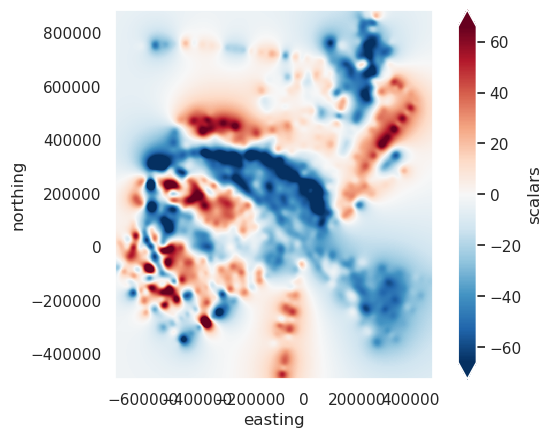

In [104]:
# Define grid coordinates
grid_coords = vd.grid_coordinates(
    region=vd.pad_region(vd.get_region(coords), 10e3),
    spacing=2000,
    extra_coords=data_df.ellipsoidal_height_m.mean(),  # upward continue
    adjust="region",
)
grid_unlevelled = eqs_unlevelled.grid(grid_coords)

# grid_unlevelled = vd.distance_mask(
#     (coords[0], coords[1]), maxdist=10e3, grid=grid_unlevelled
# )
grid_unlevelled = grid_unlevelled.reset_coords(names="upward").scalars

grid_unlevelled.plot(robust=True).axes.set_aspect("equal")

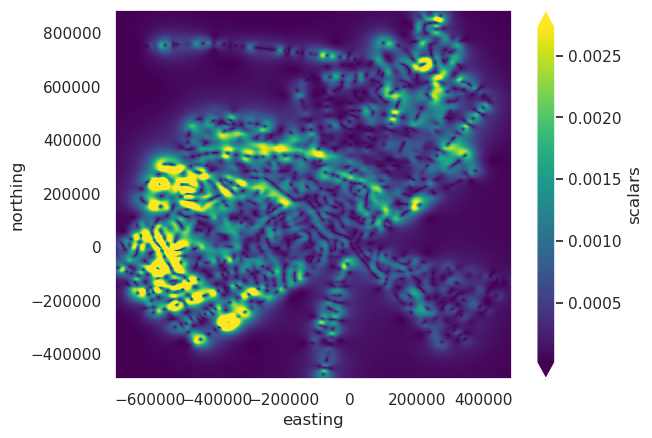

In [105]:
hg_unlevelled = airbornegeo.filter_grid(
    grid_unlevelled, filter_type="horizontal_gradient"
)
hg_unlevelled.plot(robust=True)